# SI 699 Mini Project — EDA: Visits to American National Parks

Branch: `Sikandar`. Exploratory analysis of the NPS by-month visitation dataset
(1979–2023) ahead of picking a claim for the mini project write-up.

Source: `US-National-Parks_Use_1979-2023_By-Month.csv`, from the
[Responsible Datasets in Context](https://www.responsible-datasets-in-context.com/posts/np-data/)
project (data essay cited there covers collection methods and caveats).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", font_scale=1.0)

# validated categorical palette (see dataviz skill reference/palette.md)
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
MAGENTA, GREEN, VIOLET, RED = "#e87ba4", "#008300", "#4a3aa7", "#e34948"
CAT_PALETTE = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]


## Load and clean

In [2]:
df = pd.read_csv("../data/US-National-Parks_Use_1979-2023_By-Month.csv", encoding="utf-8-sig")
df.columns = df.columns.str.strip()
for col in ["ParkName", "UnitCode", "ParkType", "Region", "State"]:
    df[col] = df[col].str.strip()

df["Date"] = pd.to_datetime(dict(year=df.Year, month=df.Month, day=1))
df["ZeroVisits"] = df["RecreationVisits"] == 0

print(df.shape)
df.head()


(33395, 14)


,ParkName,UnitCode,ParkType,Region,State,Year,Month,RecreationVisits,NonRecreationVisits,TentCampers,RVCampers,Backcountry,Date,ZeroVisits
0,Acadia NP,ACAD,National Park,Northeast,ME,1979,1,6011,15252,102,13,0,1979-01-01,False
1,Acadia NP,ACAD,National Park,Northeast,ME,1979,2,5243,13776,53,8,0,1979-02-01,False
2,Acadia NP,ACAD,National Park,Northeast,ME,1979,3,11165,15252,176,37,0,1979-03-01,False
3,Acadia NP,ACAD,National Park,Northeast,ME,1979,4,219351,37657,1037,459,0,1979-04-01,False
4,Acadia NP,ACAD,National Park,Northeast,ME,1979,5,339416,50616,3193,1148,0,1979-05-01,False


In [3]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
ParkName,33395,63,Acadia NP,540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitCode,33395,63,ACAD,540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ParkType,33395,1,National Park,33395,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,33395,6,Intermountain,10260,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,33395,30,CA,4859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,33395.0,NaN,NaN,NaN,2001.28124,1979.0,1990.0,2001.0,2012.0,2023.0,12.90109
Month,33395.0,NaN,NaN,NaN,6.499835,1.0,3.5,6.0,9.0,12.0,3.452025
RecreationVisits,33395.0,NaN,NaN,NaN,96127.651115,0.0,9998.0,40849.0,105293.5,1761918.0,166392.800126
NonRecreationVisits,33395.0,NaN,NaN,NaN,30188.234257,-32964.0,0.0,509.0,8339.0,1646888.0,115564.885294
TentCampers,33395.0,NaN,NaN,NaN,3548.919449,0.0,0.0,154.0,1980.0,179369.0,10436.616589


**Note:** 63 parks, 1979–2023, monthly granularity. `Region` and other text
columns had trailing whitespace (e.g. `"Northeast "`) — stripped above. There
are 362 rows with `RecreationVisits == 0`; the data essay notes some of these
are non-reporting gaps (e.g. Kobuk Valley 2014–15) rather than true zero visits,
so we flag rather than drop them.

## Coverage: how complete is the panel?

In [4]:
coverage = df.groupby("ParkName")["Date"].agg(["min", "max", "count"])
coverage["expected_months"] = ((coverage["max"].dt.year - coverage["min"].dt.year) * 12
                                 + (coverage["max"].dt.month - coverage["min"].dt.month) + 1)
coverage["missing"] = coverage["expected_months"] - coverage["count"]
coverage.sort_values("missing", ascending=False).head(10)


,min,max,count,expected_months,missing
ParkName,,,,,
National Park of American Samoa,2002-01-01,2023-12-01,240,264,24
Katmai NP & PRES,1979-01-01,2023-12-01,528,540,12
Channel Islands NP,1979-01-01,2023-12-01,539,540,1
Acadia NP,1979-01-01,2023-12-01,540,540,0
Petrified Forest NP,1979-01-01,2023-12-01,540,540,0
Kenai Fjords NP,1982-01-01,2023-12-01,504,504,0
Kings Canyon NP,1979-01-01,2023-12-01,540,540,0
Kobuk Valley NP,1982-01-01,2023-12-01,504,504,0
Lake Clark NP & PRES,1982-01-01,2023-12-01,504,504,0


In [5]:
zero_by_park = df.groupby("ParkName")["ZeroVisits"].sum().sort_values(ascending=False)
zero_by_park[zero_by_park > 0].head(10)


ParkName
Katmai NP & PRES                   86
Gates of the Arctic NP & PRES      69
Isle Royale NP                     58
Kobuk Valley NP                    33
Lake Clark NP & PRES               25
North Cascades NP                  17
National Park of American Samoa    15
Kenai Fjords NP                    13
Biscayne NP                         5
Virgin Islands NP                   4
Name: ZeroVisits, dtype: int64

## National totals over time

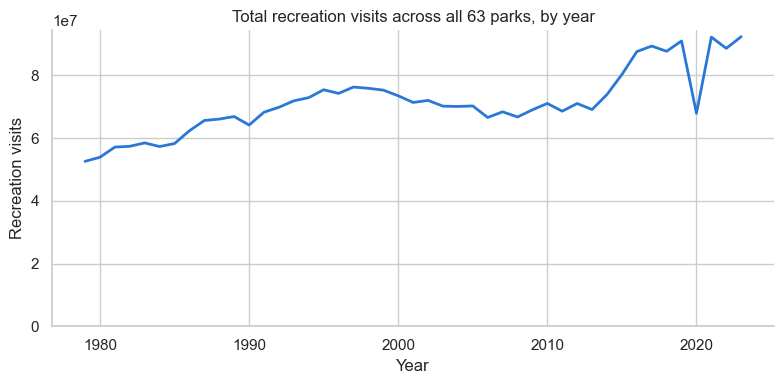

In [6]:
annual = df.groupby("Year")["RecreationVisits"].sum()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(annual.index, annual.values, color=BLUE, lw=2)
ax.set_title("Total recreation visits across all 63 parks, by year")
ax.set_xlabel("Year")
ax.set_ylabel("Recreation visits")
ax.set_ylim(bottom=0)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


National visits grew fairly steadily from 1979 to the early 2010s, dipped
sharply in 2020 (COVID-19 closures), and rebounded past prior levels by 2023.
This matches the well-known headline pattern, so it's a sanity check rather
than the interesting claim — but it confirms the data behaves as expected.

## Which parks dominate visitation?

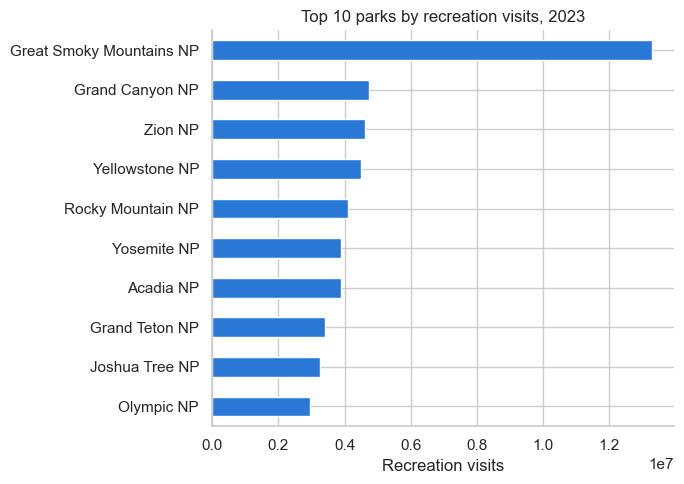

In [7]:
top_parks_2023 = (df[df.Year == 2023].groupby("ParkName")["RecreationVisits"]
                  .sum().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(7, 5))
top_parks_2023.head(10).iloc[::-1].plot(kind="barh", ax=ax, color=BLUE)
ax.set_title("Top 10 parks by recreation visits, 2023")
ax.set_xlabel("Recreation visits")
ax.set_ylabel("")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


In [8]:
print("Share of 2023 visits held by top 10 parks:",
      round(top_parks_2023.head(10).sum() / top_parks_2023.sum(), 3))
print("Share of 2023 visits held by bottom 10 parks:",
      round(top_parks_2023.tail(10).sum() / top_parks_2023.sum(), 3))


Share of 2023 visits held by top 10 parks: 0.527
Share of 2023 visits held by bottom 10 parks: 0.005


Visitation is heavily concentrated: the top 10 parks capture a large share
of all recreation visits, while many remote parks (mostly in Alaska) draw a
small fraction. This concentration is a known, not-very-interesting fact on
its own (per the assignment prompt, "most visited park" claims are too shallow) —
but it's useful context for interpreting per-park patterns below, since a few
huge parks can dominate any *unweighted* national average.

## Seasonality: when do people visit?

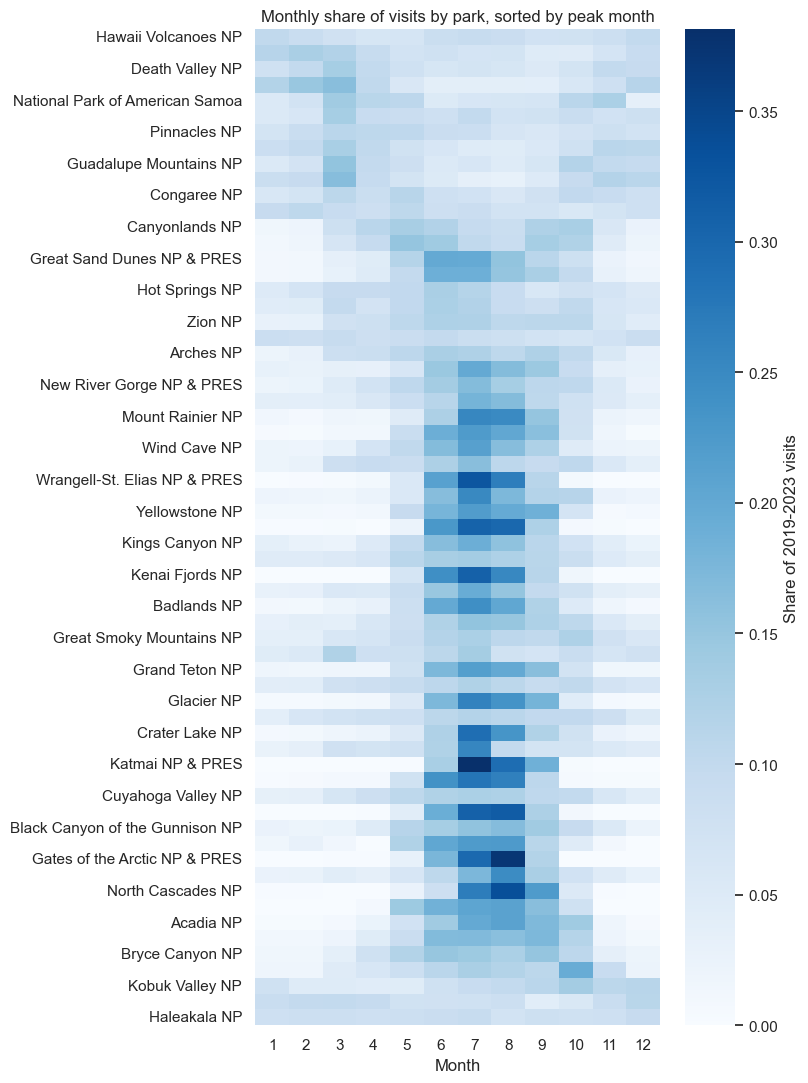

In [9]:
recent = df[df.Year.between(2019, 2023)]
park_month = (recent.groupby(["ParkName", "Month"])["RecreationVisits"].sum()
              .unstack("Month"))
park_month_norm = park_month.div(park_month.sum(axis=1), axis=0)

peak_month = park_month_norm.idxmax(axis=1)
park_order = peak_month.sort_values().index

fig, ax = plt.subplots(figsize=(8, 11))
sns.heatmap(park_month_norm.loc[park_order], cmap="Blues", ax=ax,
            cbar_kws={"label": "Share of 2019-2023 visits"})
ax.set_title("Monthly share of visits by park, sorted by peak month")
ax.set_xlabel("Month")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


Sorting parks by their peak month reveals two distinct seasonal profiles: a
cluster of desert/southern parks (Big Bend, Saguaro, Joshua Tree, Death Valley)
that peak in winter/spring, and a cluster of high-latitude/alpine parks
(Alaska parks, North Cascades, Glacier) that are extremely summer-concentrated —
some draw 80%+ of annual visits in June-August alone. Most parks fall in between,
peaking in July.

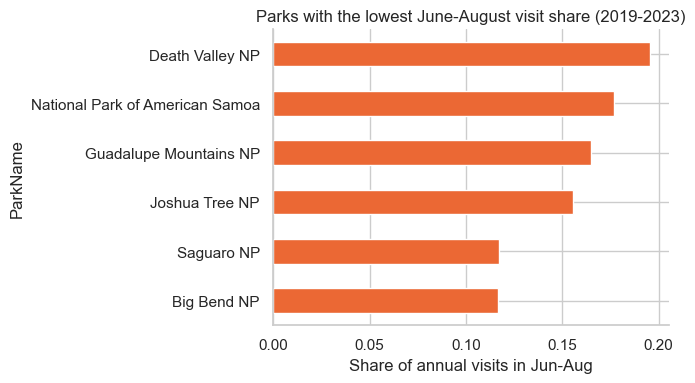

In [10]:
summer_share_by_park = park_month_norm[[6, 7, 8]].sum(axis=1).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
summer_share_by_park.head(6).plot(kind="barh", ax=ax, color=ORANGE, label="Lowest summer share")
ax.set_title("Parks with the lowest June-August visit share (2019-2023)")
ax.set_xlabel("Share of annual visits in Jun-Aug")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


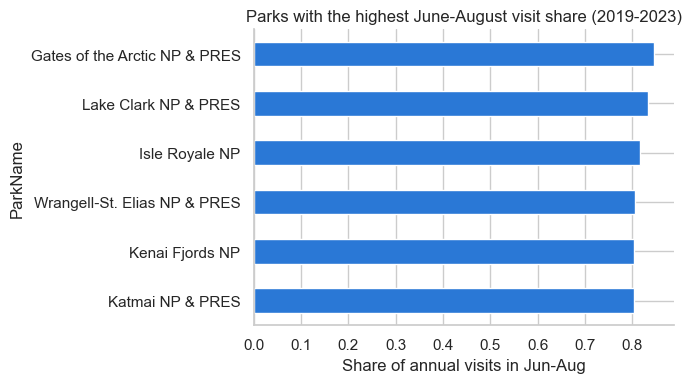

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
summer_share_by_park.tail(6).plot(kind="barh", ax=ax, color=BLUE)
ax.set_title("Parks with the highest June-August visit share (2019-2023)")
ax.set_xlabel("Share of annual visits in Jun-Aug")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


### Is the national summer concentration changing over time?

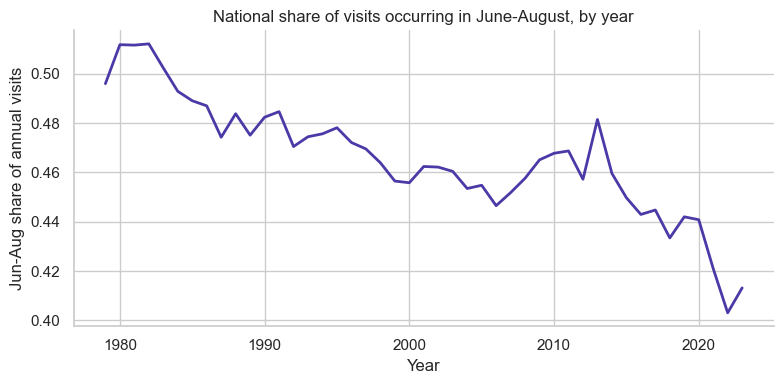

In [12]:
natl_month = df.groupby(["Year", "Month"])["RecreationVisits"].sum().unstack("Month")
summer_share_by_year = natl_month[[6, 7, 8]].sum(axis=1) / natl_month.sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(summer_share_by_year.index, summer_share_by_year.values, color=VIOLET, lw=2)
ax.set_title("National share of visits occurring in June-August, by year")
ax.set_xlabel("Year")
ax.set_ylabel("Jun-Aug share of annual visits")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


In [13]:
print(summer_share_by_year.loc[[1979, 1999, 2019, 2023]].round(3))


Year
1979    0.496
1999    0.456
2019    0.442
2023    0.413
dtype: float64


The national summer share has drifted down from roughly 0.50 in 1979 to
around 0.44 by 2019-2023 — a modest but persistent de-seasonalization, i.e.
visits are spreading more into shoulder months (spring/fall) than they used to.
This is the strongest, most defensible candidate claim from this EDA: it's a
clear trend, not just a single number, and it's measured consistently across
45 years with the same definition.

## Day-trip vs. overnight visitation

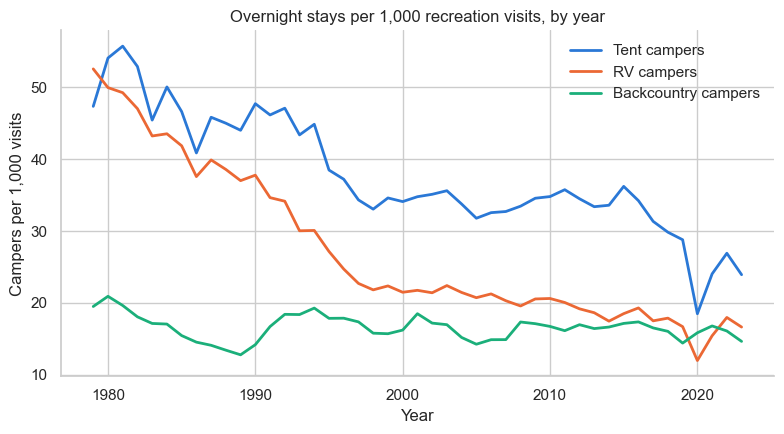

In [14]:
annual_use = df.groupby("Year")[["RecreationVisits", "TentCampers", "RVCampers", "Backcountry"]].sum()
per_1000 = annual_use[["TentCampers", "RVCampers", "Backcountry"]].div(
    annual_use["RecreationVisits"], axis=0) * 1000

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(per_1000.index, per_1000["TentCampers"], color=BLUE, lw=2, label="Tent campers")
ax.plot(per_1000.index, per_1000["RVCampers"], color=ORANGE, lw=2, label="RV campers")
ax.plot(per_1000.index, per_1000["Backcountry"], color=AQUA, lw=2, label="Backcountry campers")
ax.set_title("Overnight stays per 1,000 recreation visits, by year")
ax.set_xlabel("Year")
ax.set_ylabel("Campers per 1,000 visits")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


In [15]:
print(per_1000.loc[[1979, 1999, 2019, 2023]].round(1))


      TentCampers  RVCampers  Backcountry
Year                                     
1979         47.4       52.6         19.5
1999         34.6       22.4         15.7
2019         28.8       16.7         14.4
2023         23.9       16.6         14.7


Overnight stays have fallen sharply relative to total visits since 1979: tent
camping per 1,000 visits has dropped by nearly half, and RV camping by two
thirds. Backcountry camping is far smaller in absolute terms and has stayed
roughly flat as a rate. This suggests a shift toward day-use visitation over
time — the average visit looks less like a multi-day camping trip and more
like a shorter visit — though we can't tell from this data alone whether that's
driven by more day-trippers, shorter stays, or growth concentrated in parks
that were never camping-heavy to begin with (checked below).

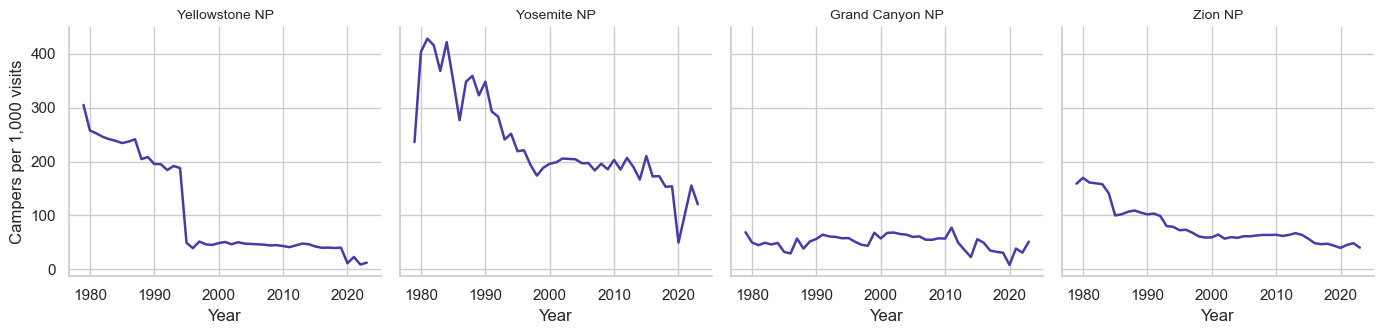

In [16]:
# Is the decline driven by mix-shift (visit growth concentrated in low-camping parks)
# or a within-park decline in camping rates? Check a few large, well-established parks.
big_parks = ["Yellowstone NP", "Yosemite NP", "Grand Canyon NP", "Zion NP"]
fig, axes = plt.subplots(1, len(big_parks), figsize=(14, 3.5), sharey=True)
for ax, park in zip(axes, big_parks):
    sub = df[df.ParkName == park].groupby("Year")[["RecreationVisits", "TentCampers", "RVCampers"]].sum()
    rate = (sub["TentCampers"] + sub["RVCampers"]) / sub["RecreationVisits"] * 1000
    ax.plot(rate.index, rate.values, color=VIOLET, lw=1.8)
    ax.set_title(park, fontsize=10)
    ax.set_xlabel("Year")
    sns.despine(ax=ax)
axes[0].set_ylabel("Campers per 1,000 visits")
plt.tight_layout()
plt.show()


The same downward trend shows up within individual long-running, high-traffic
parks (not just as a national mix-shift toward less camping-oriented parks),
which strengthens the day-use interpretation — it looks like a real change in
how people use even the classic camping destinations, not just an artifact of
which parks have grown.

## Regional trends and the 2020 shock

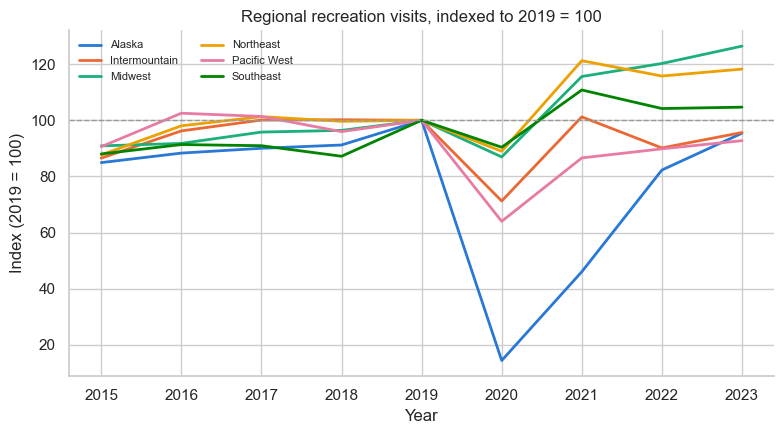

In [17]:
region_year = df.groupby(["Region", "Year"])["RecreationVisits"].sum().unstack("Year")
region_idx = region_year.div(region_year[2019], axis=0) * 100  # index to 2019 = 100

fig, ax = plt.subplots(figsize=(8, 4.5))
for color, region in zip(CAT_PALETTE, region_idx.index):
    sub = region_idx.loc[region, 2015:2023]
    ax.plot(sub.index, sub.values, lw=2, color=color, label=region)
ax.axhline(100, color="#9a9a94", lw=1, ls="--")
ax.set_title("Regional recreation visits, indexed to 2019 = 100")
ax.set_xlabel("Year")
ax.set_ylabel("Index (2019 = 100)")
ax.legend(frameon=False, fontsize=8, ncol=2)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


Every region dropped sharply in 2020, but the depth of the drop and the speed
of recovery differ by region. Regions with more remote, drive-to, outdoor-access
parks recovered faster (some exceeding their 2019 level by 2021-2022), while
regions with more urban/international-visitor-dependent parks took longer to
recover to baseline.

In [18]:
drop_2020 = region_idx[2020] - 100
recovery_2022 = region_idx[2022] - 100
comparison = pd.DataFrame({"2020 drop (pct pts vs 2019)": drop_2020,
                            "2022 vs 2019 (pct pts)": recovery_2022}).round(1)
comparison.sort_values("2020 drop (pct pts vs 2019)")


,2020 drop (pct pts vs 2019),2022 vs 2019 (pct pts)
Region,,
Alaska,-85.6,-17.7
Pacific West,-36.0,-10.2
Intermountain,-28.8,-9.9
Midwest,-13.1,20.2
Northeast,-11.0,15.8
Southeast,-9.6,4.2


Note on data quality here: the data essay flags that 2024 figures were
reportedly suppressed by the federal government, and that equipment outages
and non-reporting can produce misleading zeros in some park-years (e.g. Kobuk
Valley 2014-2015, Carlsbad Caverns' counter broken since 2019). We restrict
this by-month analysis to 2023 and earlier for that reason, and the zero-visit
flag from the cleaning step lets us check whether any region's 2020 dip is
inflated by non-reporting rather than real closures.

In [19]:
zeros_2020 = df[(df.Year == 2020) & (df.ZeroVisits)]
print(f"{len(zeros_2020)} zero-visit rows in 2020 across {zeros_2020.ParkName.nunique()} parks")
zeros_2020[["ParkName", "Month", "Region"]]


46 zero-visit rows in 2020 across 26 parks


,ParkName,Month,Region
1035,Arches NP,4,Intermountain
2115,Big Bend NP,4,Intermountain
2116,Big Bend NP,5,Intermountain
2118,Big Bend NP,7,Intermountain
4275,Canyonlands NP,4,Intermountain
6362,Congaree NP,4,Southeast
10103,Gates of the Arctic NP & PRES,1,Alaska
10104,Gates of the Arctic NP & PRES,2,Alaska
10105,Gates of the Arctic NP & PRES,3,Alaska
10106,Gates of the Arctic NP & PRES,4,Alaska
